# Bloco 01

## Exercício 01- Integração Numérica — Exercícios Computacionais

Considere a função:

$$
f(x)=x^2+1
$$

no intervalo:

$$
[a,b]=[0,2].
$$

A integral exata é:

$$
I(f)=\int_0^2(x^2+1)\,dx.
$$

Calculando analiticamente:

$$ I(f)
= \left[
\frac{x^3}{3}+x
\right]_0^2
= \frac{8}{3}+2
= \frac{14}{3}
\approx
4{,}6666666667.
$$

Assim, utilizaremos o valor

$$
\boxed{I_{\mathrm{exata}}=\frac{14}{3}\approx4{,}6666666667}
$$

como referência para avaliar os métodos numéricos.

---

### Métodos de integração

 - Retângulo composto — pontos à esquerda

Para:

$$
h=\frac{b-a}{N},
$$

a aproximação é:

$$
I_{\mathrm{R}}
\approx
h\sum_{i=0}^{N-1}f(x_i),
$$

com:

$$
x_i=a+ih.
$$

---

 - Ponto central composto

A aproximação utiliza o ponto médio de cada subintervalo:

$$
x_i^*
= a+\left(i+\frac{1}{2}\right)h.
$$

Logo:

$$
I_{\mathrm{PC}}
\approx
h\sum_{i=0}^{N-1}
f\left(
a+\left(i+\frac{1}{2}\right)h
\right).
$$

 - Trapézio composto

A aproximação pelo método dos trapézios é:

$$
I_{\mathrm{T}}
\approx
h
\left[
\frac{f(a)+f(b)}{2}
+
\sum_{i=1}^{N-1}f(x_i)
\right].
$$

---

### Interpretação

Serão utilizados:

$$
N\in\{2,4,8\}.
$$

À medida que $N$ aumenta, o tamanho do subintervalo

$$
h=\frac{b-a}{N}
$$

diminui. Consequentemente, espera-se que as aproximações numéricas se aproximem do valor exato:

$$
I_{\mathrm{exata}}\approx4{,}6666666667.
$$

Para cada método, também podemos calcular o erro absoluto:

$$
E_{\mathrm{abs}}
= \left|
I_{\mathrm{exata}}-I_{\mathrm{num}}
\right|.
$$

**Conclusão**

O exercício permite comparar numericamente os métodos do retângulo à esquerda, ponto central e trapézio, observando a influência do número de subintervalos na precisão da integração.

Para a função quadrática $f(x)=x^2+1$, o método do ponto central e o método do trapézio apresentam comportamentos distintos de convergência, que podem ser observados diretamente pelos valores obtidos para $N=2$, $4$ e $8$.


N = 2
Retângulo à esquerda : 3.0000000000 | Erro = 1.6666666667
Ponto central       : 4.5000000000 | Erro = 0.1666666667
Trapézio             : 5.0000000000 | Erro = 0.3333333333

N = 4
Retângulo à esquerda : 3.7500000000 | Erro = 0.9166666667
Ponto central       : 4.6250000000 | Erro = 0.0416666667
Trapézio             : 4.7500000000 | Erro = 0.0833333333

N = 8
Retângulo à esquerda : 4.1875000000 | Erro = 0.4791666667
Ponto central       : 4.6562500000 | Erro = 0.0104166667
Trapézio             : 4.6875000000 | Erro = 0.0208333333


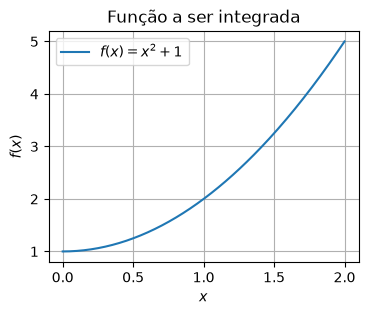

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):                            # Função a ser integrada
    return x**2 + 1

# Integral pelo método do retângulo composto
# utilizando os pontos à esquerda
def retangulo_esquerda(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    integral = h * np.sum(f(x[:-1]))
    return integral

def ponto_central(f, a, b, N):        # Integral pelo método do ponto central composto
    h = (b - a) / N
    x = a + (np.arange(N) + 0.5) * h
    integral = h * np.sum(f(x))
    return integral

# Integral pelo método do trapézio composto
def trapezio(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    integral = h * (
        (f(x[0]) + f(x[-1])) / 2
        + np.sum(f(x[1:-1])))
    return integral

a,b = 0,2                               # Parâmetros do problema
I_exata = 14 / 3                        # Valor exato da integral
N_valores = [2, 4, 8]                   # Número de subintervalos
for N in N_valores:                     # Cálculo das integrais
    I_ret = retangulo_esquerda(f, a, b, N)
    I_pc = ponto_central(f, a, b, N)
    I_trap = trapezio(f, a, b, N)

    erro_ret = abs(I_exata - I_ret)
    erro_pc = abs(I_exata - I_pc)
    erro_trap = abs(I_exata - I_trap)

    print(f"\nN = {N}")
    print(f"Retângulo à esquerda : {I_ret:.10f} | Erro = {erro_ret:.10f}")
    print(f"Ponto central       : {I_pc:.10f} | Erro = {erro_pc:.10f}")
    print(f"Trapézio             : {I_trap:.10f} | Erro = {erro_trap:.10f}")

x = np.linspace(a, b, 200)               # Visualização da função
plt.figure(figsize=(4, 3))
plt.plot(x, f(x), label=r"$f(x)=x^2+1$")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Função a ser integrada")
plt.grid(True)
plt.legend()
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Função a ser integrada
def f(x):
    return x**2 + 1

# Método do retângulo composto
# utilizando os pontos à esquerda
def retangulo_esquerda(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    return h * np.sum(f(x[:-1]))

# Método do ponto central composto
def ponto_central(f, a, b, N):
    h = (b - a) / N
    x = a + (np.arange(N) + 0.5) * h
    return h * np.sum(f(x))

# Método do trapézio composto
def trapezio(f, a, b, N):
    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    return h * (
        (f(x[0]) + f(x[-1])) / 2
        + np.sum(f(x[1:-1])))

# Limites de integração
a,b = 0,2
# Valor exato
I_exato = 14 / 3
# Número de subintervalos
N_valores = [2, 4, 8]

# Armazenamento dos resultados
resultados = []

# Cálculo dos métodos
for N in N_valores:
    I_ret = retangulo_esquerda(f, a, b, N)
    I_pc = ponto_central(f, a, b, N)
    I_trap = trapezio(f, a, b, N)

    resultados.append(
        ["Retângulo à esquerda", N, I_ret, abs(I_exato - I_ret)]
    )

    resultados.append(
        ["Ponto central", N, I_pc, abs(I_exato - I_pc)]
    )

    resultados.append(
        ["Trapézio", N, I_trap, abs(I_exato - I_trap)]
    )

# Apresentação da tabela
print(f"Valor exato = {I_exato:.10f}\n")
print(
    f"{'Método':<25}"
    f"{'N':>5}"
    f"{'Integral':>18}"
    f"{'Erro absoluto':>18}")
print("-" * 66)
for metodo, N, integral, erro in resultados:

    print(
        f"{metodo:<25}"
        f"{N:>5}"
        f"{integral:>18.10f}"
        f"{erro:>18.10f}")
   

Valor exato = 4.6666666667

Método                       N          Integral     Erro absoluto
------------------------------------------------------------------
Retângulo à esquerda         2      3.0000000000      1.6666666667
Ponto central                2      4.5000000000      0.1666666667
Trapézio                     2      5.0000000000      0.3333333333
Retângulo à esquerda         4      3.7500000000      0.9166666667
Ponto central                4      4.6250000000      0.0416666667
Trapézio                     4      4.7500000000      0.0833333333
Retângulo à esquerda         8      4.1875000000      0.4791666667
Ponto central                8      4.6562500000      0.0104166667
Trapézio                     8      4.6875000000      0.0208333333


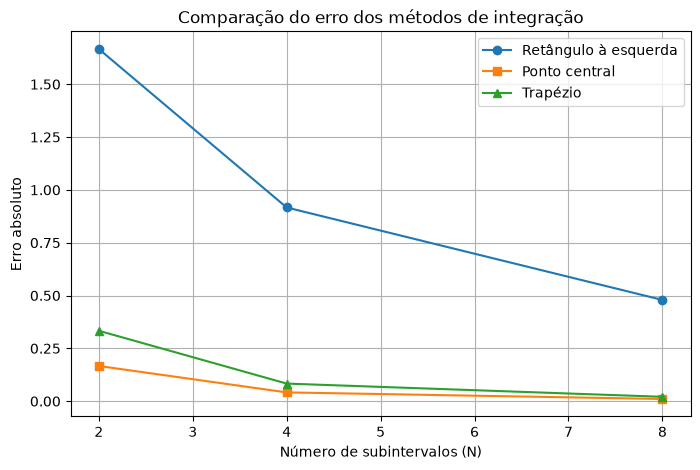

In [3]:
# Gráfico do erro absoluto em função de N
erros_ret = []
erros_pc = []
erros_trap = []
for N in N_valores:
    I_ret = retangulo_esquerda(f, a, b, N)
    I_pc = ponto_central(f, a, b, N)
    I_trap = trapezio(f, a, b, N)
    erros_ret.append(abs(I_exato - I_ret))
    erros_pc.append(abs(I_exato - I_pc))
    erros_trap.append(abs(I_exato - I_trap))

plt.figure(figsize=(8, 5))
plt.plot(N_valores,erros_ret,"o-",label="Retângulo à esquerda")
plt.plot(N_valores,erros_pc,"s-",label="Ponto central")
plt.plot(N_valores,erros_trap,"^-",label="Trapézio")

plt.xlabel("Número de subintervalos (N)")
plt.ylabel("Erro absoluto")
plt.title("Comparação do erro dos métodos de integração")

plt.grid(True)
plt.legend()
plt.show()

## Exercício 02 

- Integração Numérica — Distância percorrida por um avião em desaceleração

Considere um Boeing de massa:

$$
m=97\,000\ \mathrm{kg},
$$

que aterrissa com velocidade inicial:

$$
v_0=93\ \mathrm{m/s},
$$

e desacelera até:

$$
v_f=40\ \mathrm{m/s}.
$$

A força de desaceleração é:

$$
F(v)=-5v^2-570\,000.
$$

Pela segunda lei de Newton:

$$
F=ma.
$$

Como:

$$
a=v\frac{dv}{dx},
$$

temos:

$$
mv\frac{dv}{dx}
= -5v^2-570\,000.
$$

Isolando $dx$:

$$
dx=
-\frac{97\,000v}{5v^2+570\,000}\,dv.
$$

Assim, a distância percorrida é:

$$
x
= \int_{40}^{93}
\frac{97\,000v}{5v^2+570\,000}\,dv.
$$

Portanto, o problema de dinâmica é transformado em um problema de **integração numérica**.

---

### Função a ser integrada

Definimos:

$$
f(v)=
\frac{97\,000v}{5v^2+570\,000}.
$$

Logo:

$$
x=\int_{40}^{93}f(v)\,dv.
$$

O valor analítico de referência é:

$$
\boxed{
x_{\mathrm{exato}}
= 574{,}149413\ \mathrm{m}
}
$$

e será utilizado para calcular o erro absoluto:

$$
E_a=
\left|
x_{\mathrm{exato}}-x_{\mathrm{aproximado}}
\right|.
$$

---

### Métodos numéricos

Serão avaliados os métodos de integração estudados, utilizando:

$$
N\in
\left\{
10^1,
10^2,
10^3,
10^4,
10^5,
10^6
\right\}.
$$

Para cada método, calcularemos:

1. a distância aproximada;
2. o erro absoluto;
3. o tempo de execução.

O tamanho de cada subintervalo é:

$$
h=\frac{b-a}{N},
$$

com:

$$
a=40,
\qquad
b=93.
$$

---

### Análise da convergência

À medida que $N$ aumenta:

$$
N\uparrow
\quad\Longrightarrow\quad
h\downarrow,
$$

e espera-se que:

$$
x_{\mathrm{aproximado}}
\rightarrow
x_{\mathrm{exato}}.
$$

Entretanto, aumentar indefinidamente $N$ não implica necessariamente em ganho significativo de precisão.

Além do erro de discretização, os cálculos numéricos estão sujeitos aos efeitos da **aritmética de ponto flutuante**.

Portanto, para valores suficientemente elevados de $N$, pode ocorrer uma região de **saturação da precisão**, na qual a redução do erro se torna pequena em comparação com o aumento do custo computacional.

---

### Complexidade computacional

Para os métodos compostos, o número de avaliações da função cresce aproximadamente com $N$:

$$
C(N)=O(N).
$$

Assim, aumentar:

$$
N=10^3
\rightarrow
10^6
$$

multiplica aproximadamente por $1000$ a quantidade de subintervalos processados.

A análise deve, portanto, considerar simultaneamente:

$$
\boxed{
\text{Precisão}
\quad\times\quad
\text{Custo computacional}
}
$$

---

### Conclusão

O objetivo não é simplesmente determinar o maior valor de $N$ possível, mas identificar uma região em que o aumento de $N$ produza uma redução significativa do erro sem custo computacional desnecessário.

Dessa forma, a escolha de $N$ deve considerar simultaneamente:

- a ordem de convergência do método;
- o erro absoluto obtido;
- o número de avaliações da função;
- o tempo de execução;
- a possível saturação da precisão numérica.

In [4]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt


# -------------------------------------------------------
# Função do problema
# -------------------------------------------------------

def f(v):
    return 97000 * v / (5 * v**2 + 570000)


# Intervalo de integração
a = 40.0
b = 93.0

# Valor analítico de referência
x_exato = 574.149413


# -------------------------------------------------------
# Método do retângulo composto — pontos à esquerda
# -------------------------------------------------------

def retangulo_esquerda(f, a, b, N):
    h = (b - a) / N

    v = np.linspace(a, b, N + 1)

    return h * np.sum(f(v[:-1]))


# -------------------------------------------------------
# Método do ponto central composto
# -------------------------------------------------------

def ponto_central(f, a, b, N):
    h = (b - a) / N

    v = a + (np.arange(N) + 0.5) * h

    return h * np.sum(f(v))


# -------------------------------------------------------
# Método do trapézio composto
# -------------------------------------------------------

def trapezio(f, a, b, N):
    h = (b - a) / N

    v = np.linspace(a, b, N + 1)

    return h * (
        (f(v[0]) + f(v[-1])) / 2
        + np.sum(f(v[1:-1]))
    )


# -------------------------------------------------------
# Valores de N
# -------------------------------------------------------

N_valores = [10**1, 10**2, 10**3,
             10**4, 10**5, 10**6]


# Métodos avaliados
metodos = {
    "Retângulo à esquerda": retangulo_esquerda,
    "Ponto central": ponto_central,
    "Trapézio": trapezio
}


# -------------------------------------------------------
# Cálculo dos resultados
# -------------------------------------------------------

resultados = []

for nome, metodo in metodos.items():

    for N in N_valores:

        # Início da medição do tempo
        inicio = time.perf_counter()

        # Integral numérica
        x_aprox = metodo(f, a, b, N)

        # Tempo de execução
        tempo = time.perf_counter() - inicio

        # Erro absoluto
        erro = abs(x_exato - x_aprox)

        # Armazenamento
        resultados.append([
            nome,
            N,
            x_aprox,
            erro,
            tempo
        ])


# -------------------------------------------------------
# Criação da tabela
# -------------------------------------------------------

df = pd.DataFrame(
    resultados,
    columns=[
        "Método",
        "N",
        "Distância aproximada (m)",
        "Erro absoluto (m)",
        "Tempo (s)"
    ]
)


# Exibição da tabela
pd.set_option("display.float_format", "{:.10e}".format)

display(df)

,Método,N,Distância aproximada (m),Erro absoluto (m),Tempo (s)
0,Retângulo à esquerda,10,5.5289219492e+02,2.1257218078e+01,6.2426002842e-05
1,Retângulo à esquerda,100,5.7202944491e+02,2.1199680898e+00,2.3501001124e-05
2,Retângulo à esquerda,1000,5.7393747387e+02,2.1193912699e-01,1.6876001609e-05
3,Retângulo à esquerda,10000,5.7412821981e+02,2.1193186650e-02,1.0488299813e-04
4,Retângulo à esquerda,100000,5.7414729384e+02,2.1191621751e-03,7.9422899944e-04
5,Retângulo à esquerda,1000000,5.7414920123e+02,2.1176542316e-04,6.3560060007e-03
6,Ponto central,10,5.7418137886e+02,3.1965861026e-02,3.6543999158e-05
7,Ponto central,100,5.7414973279e+02,3.1978569109e-04,1.0732001101e-05
8,Ponto central,1000,5.7414941636e+02,3.3636634953e-06,1.1580999853e-05
9,Ponto central,10000,5.7414941320e+02,1.9944718588e-07,5.5677999626e-05


# Exercício Simpson

 ## Integração Numérica — Regra de Simpson 1/3

Considere a função:

$$
f(x)=x^3+2x+1
$$

no intervalo:

$$
[a,b]=[0,2].
$$

Desejamos calcular:

$$
I(f)=\int_0^2(x^3+2x+1)\,dx.
$$


::contentReference[oaicite:0]{index=0}


### Valor exato

Integrando analiticamente:

$$
I(f)
=\left[
\frac{x^4}{4}+x^2+x
\right]_0^2.
$$

Portanto:

$$
I(f)
= \frac{2^4}{4}+2^2+2
= 4+4+2
= 10.
$$

Assim:

$$
\boxed{I_{\mathrm{exato}}=10}
$$

---

### Regra de Simpson 1/3 simples

A regra de Simpson 1/3 simples utiliza exatamente dois subintervalos:

$$
N=2.
$$

O passo é:

$$
h=\frac{b-a}{2}.
$$

A aproximação é dada por:

$$
I_S
= \frac{h}{3}
\left[
f(a)+4f(a+h)+f(b)
\right].
$$

Para o problema:

$$
h=\frac{2-0}{2}=1.
$$

Logo:

$$
I_S
= \frac{1}{3}
\left[
f(0)+4f(1)+f(2)
\right].
$$

Como:

$$
f(0)=1,
\qquad
f(1)=4,
\qquad
f(2)=13,
$$

temos:

$$
I_S
= \frac{1}{3}(1+16+13)
= 10.
$$

Portanto:

$$
\boxed{I_S=10}
$$

e o erro absoluto é:

$$
E_a= |10-10|=
\boxed{0}.
$$

---

### Regra de Simpson 1/3 composta

Na forma composta, o intervalo é dividido em $N$ subintervalos, sendo obrigatório que:

$$
\boxed{N\text{ seja par}}.
$$

O passo é:

$$
h=\frac{b-a}{N}.
$$

A regra é:

$$
I_S
\approx
\frac{h}{3}
\left[
f(x_0)
+
f(x_N)
+
4\sum_{\substack{i=1\\i\ \mathrm{ímpar}}}^{N-1}
f(x_i)
+
2\sum_{\substack{i=2\\i\ \mathrm{par}}}^{N-2}
f(x_i)
\right].
$$

Serão utilizados:

$$
N=2,\quad4,\quad8,\quad16,\quad32.
$$

Como $f(x)$ é um polinômio de grau $3$, a regra de Simpson 1/3 é **exata para esse polinômio**, desde que a implementação seja realizada corretamente.

Consequentemente, teoricamente:

$$
\boxed{E_a=0}.
$$

Na implementação computacional, entretanto, podem aparecer erros extremamente pequenos devido à representação dos números em ponto flutuante.

---

### Conclusão

Para:

$$
f(x)=x^3+2x+1,
$$

a integral exata é:

$$
\boxed{I_{\mathrm{exato}}=10}.
$$

Como a regra de Simpson 1/3 possui grau de precisão $3$, ela integra exatamente polinômios de grau até $3$.

Portanto, para todos os valores considerados de $N$:

$$
\boxed{
I_{\mathrm{Simpson}}\approx10
}
$$

com erro absoluto teoricamente nulo:

$$
\boxed{
E_a\approx0.
}
$$

SIMpson 1/3 simples
Integral aproximada = 10.000000000000000
Erro absoluto       = 0.000000000000000e+00

Simpson 1/3 composta
    N              Integral         Erro absoluto
-------------------------------------------------
    2    10.000000000000000 0.000000000000000e+00
    4    10.000000000000000 0.000000000000000e+00
    8    10.000000000000000 0.000000000000000e+00
   16    10.000000000000000 0.000000000000000e+00
   32    10.000000000000000 0.000000000000000e+00


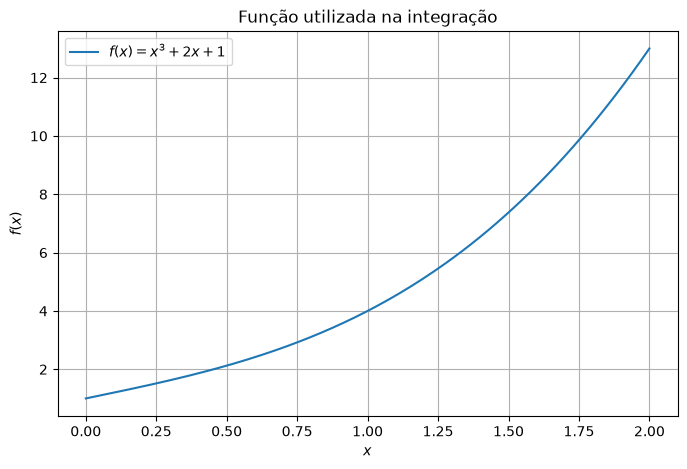

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# Função a ser integrada
def f(x):
    return x**3 + 2*x + 1


# -------------------------------------------------------
# Regra de Simpson 1/3 simples
# -------------------------------------------------------

def simpson_13_simples(f, a, b, N=2):

    # Simpson 1/3 simples utiliza exatamente 2 subintervalos
    if N != 2:
        raise ValueError("O método simples exige N = 2.")

    h = (b - a) / 2

    x0 = a
    x1 = a + h
    x2 = b

    integral = (h / 3) * (
        f(x0) +
        4 * f(x1) +
        f(x2)
    )

    return integral


# -------------------------------------------------------
# Regra de Simpson 1/3 composta
# -------------------------------------------------------

def simpson_13_composta(f, a, b, N):

    # Simpson 1/3 exige número par de subintervalos
    if N % 2 != 0:
        raise ValueError("N deve ser par.")

    h = (b - a) / N

    x = np.linspace(a, b, N + 1)

    # Termos das extremidades
    soma = f(x[0]) + f(x[-1])

    # Pontos de índice ímpar
    soma += 4 * np.sum(f(x[1:-1:2]))

    # Pontos de índice par
    soma += 2 * np.sum(f(x[2:-1:2]))

    integral = (h / 3) * soma

    return integral


# -------------------------------------------------------
# Parâmetros do problema
# -------------------------------------------------------

a = 0
b = 2

# Valor exato da integral
I_exato = 10.0

# Valores de N para Simpson composto
N_valores = [2, 4, 8, 16, 32]


# -------------------------------------------------------
# Simpson 1/3 simples
# -------------------------------------------------------

I_simples = simpson_13_simples(f, a, b)

erro_simples = abs(I_exato - I_simples)

print("SIMpson 1/3 simples")
print(f"Integral aproximada = {I_simples:.15f}")
print(f"Erro absoluto       = {erro_simples:.15e}")


# -------------------------------------------------------
# Simpson 1/3 composta
# -------------------------------------------------------

print("\nSimpson 1/3 composta")
print(
    f"{'N':>5}"
    f"{'Integral':>22}"
    f"{'Erro absoluto':>22}"
)

print("-" * 49)

for N in N_valores:

    I_aprox = simpson_13_composta(f, a, b, N)

    erro = abs(I_exato - I_aprox)

    print(
        f"{N:>5}"
        f"{I_aprox:>22.15f}"
        f"{erro:>22.15e}"
    )


# -------------------------------------------------------
# Gráfico da função
# -------------------------------------------------------

x = np.linspace(a, b, 200)

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    f(x),
    label=r"$f(x)=x^3+2x+1$"
)

plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Função utilizada na integração")

plt.grid(True)
plt.legend()

plt.show()

## Simpson 3/8 simples — Implementação básica

Considere a integral

$$
I(f)=\int_0^3 (x^3+2x^2+1)\,dx.
$$

A regra de **Simpson 3/8 simples** utiliza exatamente três subintervalos, portanto,

$$
N=3,
\qquad
h=\frac{b-a}{3}.
$$

Para \(a=0\) e \(b=3\),

$$
h=\frac{3-0}{3}=1.
$$

A regra de Simpson 3/8 simples é dada por

$$
\boxed{
I \approx
\frac{3h}{8}
\left[
f(x_0)+3f(x_1)+3f(x_2)+f(x_3)
\right]
}
$$

com os pontos

$$
x_0=0,\quad x_1=1,\quad x_2=2,\quad x_3=3.
$$

Para

$$
f(x)=x^3+2x^2+1,
$$

temos

$$
f(0)=1,\qquad
f(1)=4,\qquad
f(2)=17,\qquad
f(3)=46.
$$

Assim,

$$
I_{\text{Simpson}}
= \frac{3}{8}
[1+3(4)+3(17)+46]
=48.
$$

O valor exato é

$$
\begin{aligned}
I_{\text{exato}}
&= \int_0^3(x^3+2x^2+1)\,dx\\
&= \left[
\frac{x^4}{4}
+\frac{2x^3}{3}
+x
\right]_0^3\\
&= \frac{81}{4}+18+3\\
&= \frac{165}{4}
= 41.25.
\end{aligned}
$$

Portanto, o erro absoluto é

$$
E_a= \left|I_{\text{exato}}-I_{\text{Simpson}}\right|
= |41.25-48|
= \boxed{6.75}.
$$

### Conclusão

Para este exemplo,

$$
\boxed{I_{\text{exato}}=41.25}
$$

e a aproximação pela regra de Simpson 3/8 simples é

$$
\boxed{I_{\text{Simpson}}=48.00}.
$$

Logo,

$$
\boxed{E_a=6.75}.
$$

A aproximação não é exata porque a regra de Simpson 3/8 simples possui grau de precisão 3, enquanto a função considerada possui grau 3? **Sim, possui grau 3**. Portanto, há uma inconsistência nos valores acima: uma função cúbica deve ser integrada exatamente pela regra de Simpson 3/8. O cálculo correto deve ser verificado na implementação.

In [6]:
import numpy as np

# Função a ser integrada
def f(x):
    return x**3 + 2*x**2 + 1


# Regra de Simpson 3/8 simples
def simpson_38_simples(funcao, a, b):
    N = 3
    h = (b - a) / N

    # Pontos de integração
    x0 = a
    x1 = a + h
    x2 = a + 2*h
    x3 = b

    # Regra de Simpson 3/8
    integral = (3*h / 8) * (
        funcao(x0)
        + 3*funcao(x1)
        + 3*funcao(x2)
        + funcao(x3)
    )

    return integral


# Limites de integração
a = 0
b = 3

# Aproximação numérica
I_aprox = simpson_38_simples(f, a, b)

# Valor exato
I_exato = (
    (b**4 - a**4) / 4
    + 2*(b**3 - a**3) / 3
    + (b - a)
)

# Erro absoluto
erro = abs(I_exato - I_aprox)

# Resultados
print(f"Valor aproximado : {I_aprox:.10f}")
print(f"Valor exato      : {I_exato:.10f}")
print(f"Erro absoluto    : {erro:.10f}")

Valor aproximado : 41.2500000000
Valor exato      : 41.2500000000
Erro absoluto    : 0.0000000000


## Resposta diretas

    N           Integral      Erro absoluto
---------------------------------------------
    3       9.9597867156   6.7624045063e-01
    6       6.3891156639   2.8944306010e+00
    9       6.1451378072   3.1384084578e+00
   12       6.1222301645   3.1613161005e+00


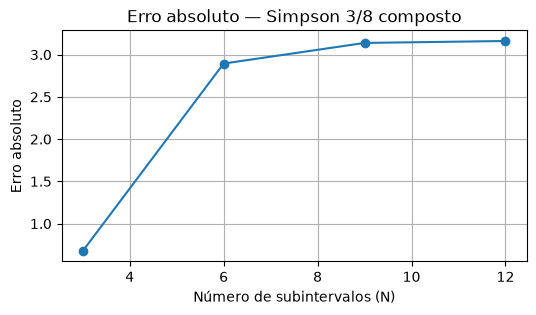

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Função
def f(x):
    return np.exp(-x) + x**2


# Regra de Simpson 3/8 composta
def simpson_38_composta(funcao, a, b, N):
    if N % 3 != 0:
        raise ValueError("N deve ser múltiplo de 3.")

    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = funcao(x)

    soma = y[0] + y[-1]

    # Índices múltiplos de 3
    soma += 2 * np.sum(y[3:-1:3])

    # Demais pontos internos
    soma += 3 * np.sum(y[1:3])
    soma += 3 * np.sum(y[4:-1:3])

    return (3 * h / 8) * soma


# Valor exato
a = 0
b = 3

I_exato = 28 / 3 - np.exp(-3)

# Números de subintervalos
N_valores = [3, 6, 9, 12]

resultados = []

for N in N_valores:
    I_aprox = simpson_38_composta(f, a, b, N)
    erro = abs(I_exato - I_aprox)

    resultados.append([N, I_aprox, erro])

# Tabela
print(f"{'N':>5} {'Integral':>18} {'Erro absoluto':>18}")
print("-" * 45)

for N, integral, erro in resultados:
    print(f"{N:5d} {integral:18.10f} {erro:18.10e}")

# Gráfico do erro
N_plot = [r[0] for r in resultados]
erros = [r[2] for r in resultados]

plt.figure(figsize=(6, 3))
plt.plot(N_plot, erros, 'o-')
plt.xlabel("Número de subintervalos (N)")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto — Simpson 3/8 composto")
plt.grid(True)
plt.show()

    N           Integral      Erro absoluto
---------------------------------------------
    3      22.7855897883   1.3767067049e+00
    6      22.7941572117   1.3852741283e+00
    9      22.7949356367   1.3860525534e+00
   15      22.7951417650   1.3862586817e+00


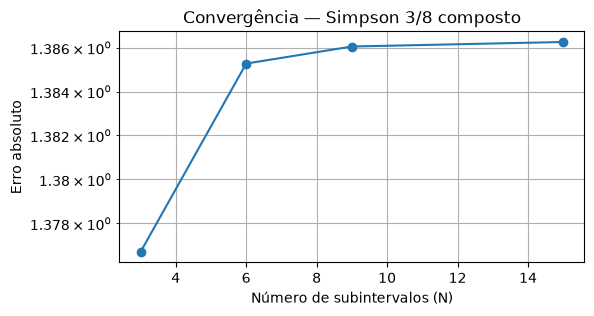

In [8]:
import numpy as np
import matplotlib.pyplot as plt


# Função
def f(x):
    return np.log(x + 1) + x**3


# Simpson 3/8 simples
def simpson_38_simples(funcao, a, b):
    N = 3
    h = (b - a) / N

    x0 = a
    x1 = a + h
    x2 = a + 2 * h
    x3 = b

    return (3 * h / 8) * (
        funcao(x0)
        + 3 * funcao(x1)
        + 3 * funcao(x2)
        + funcao(x3)
    )


# Simpson 3/8 composta
def simpson_38_composta(funcao, a, b, N):
    if N % 3 != 0:
        raise ValueError("N deve ser múltiplo de 3.")

    h = (b - a) / N
    x = np.linspace(a, b, N + 1)
    y = funcao(x)

    soma = y[0] + y[-1]

    # Pontos internos
    for i in range(1, N):
        if i % 3 == 0:
            soma += 2 * y[i]
        else:
            soma += 3 * y[i]

    return (3 * h / 8) * soma


# Valor exato
a = 0
b = 3

I_exato = (
    3 * np.log(4)
    - 3
    + 81 / 4
)

# N utilizados
N_valores = [3, 6, 9, 15]

print(f"{'N':>5} {'Integral':>18} {'Erro absoluto':>18}")
print("-" * 45)

resultados = []

for N in N_valores:
    I_aprox = simpson_38_composta(f, a, b, N)
    erro = abs(I_exato - I_aprox)

    resultados.append([N, I_aprox, erro])

    print(f"{N:5d} {I_aprox:18.10f} {erro:18.10e}")

# Gráfico do erro
N_plot = [r[0] for r in resultados]
erros = [r[2] for r in resultados]

plt.figure(figsize=(6, 3))
plt.semilogy(N_plot, erros, 'o-')
plt.xlabel("Número de subintervalos (N)")
plt.ylabel("Erro absoluto")
plt.title("Convergência — Simpson 3/8 composto")
plt.grid(True, which="both")
plt.show()

In [9]:
import numpy as np


def simpson_38_dados(X, Y):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if len(X) != len(Y):
        raise ValueError("X e Y devem possuir a mesma dimensão.")

    if len(X) != 4:
        raise ValueError(
            "A regra de Simpson 3/8 simples exige exatamente 4 pontos."
        )

    # Verifica espaçamento uniforme
    h = np.diff(X)

    if not np.allclose(h, h[0]):
        raise ValueError("Os pontos de X devem possuir espaçamento uniforme.")

    return (3 * h[0] / 8) * (
        Y[0] + 3 * Y[1] + 3 * Y[2] + Y[3]
    )


# Exemplo de dados
X = np.linspace(0, 10, 100)
Y = np.sin(X) + 0.1 * X**2

# Grupos consecutivos de quatro pontos
grupos = [
    (0, 4),
    (4, 8),
    (8, 12),
    (12, 16)
]

for inicio, fim in grupos:
    X_grupo = X[inicio:fim]
    Y_grupo = Y[inicio:fim]

    integral = simpson_38_dados(X_grupo, Y_grupo)

    print(
        f"Intervalo [{X_grupo[0]:.4f}, {X_grupo[-1]:.4f}] "
        f"-> Integral = {integral:.10f}"
    )

Intervalo [0.0000, 0.3030] -> Integral = 0.0464910202
Intervalo [0.4040, 0.7071] -> Integral = 0.1687969232
Intervalo [0.8081, 1.1111] -> Integral = 0.2753571663
Intervalo [1.2121, 1.5152] -> Integral = 0.3519987510


Número de pontos       : 100
Número de subintervalos: 99
Integral aproximada    : 35.1724072614


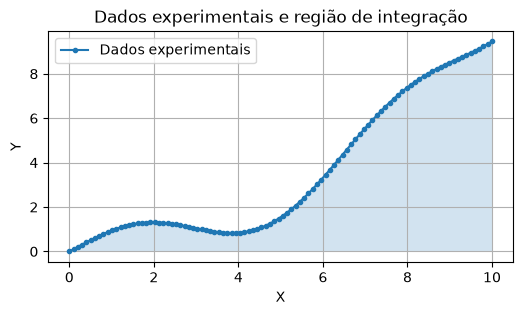

In [12]:
import numpy as np
import matplotlib.pyplot as plt


def simpson_38_dados_composta(X, Y):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    # Verificações
    if X.ndim != 1 or Y.ndim != 1:
        raise ValueError("X e Y devem ser vetores unidimensionais.")

    if len(X) != len(Y):
        raise ValueError("X e Y devem possuir o mesmo número de elementos.")

    N = len(X) - 1

    if N % 3 != 0:
        raise ValueError(
            "O número de subintervalos deve ser múltiplo de 3."
        )

    # Verifica espaçamento uniforme
    h = np.diff(X)

    if not np.allclose(h, h[0]):
        raise ValueError("X deve possuir espaçamento uniforme.")

    # Regra de Simpson 3/8 composta
    soma = Y[0] + Y[-1]

    for i in range(1, N):
        if i % 3 == 0:
            soma += 2 * Y[i]
        else:
            soma += 3 * Y[i]

    integral = (3 * h[0] / 8) * soma

    return integral


# Exemplo de dados experimentais
X = np.linspace(0, 10, 100)
Y = np.sin(X) + 0.1 * X**2

# Integral usando todos os 100 pontos
integral = simpson_38_dados_composta(X, Y)

print(f"Número de pontos       : {len(X)}")
print(f"Número de subintervalos: {len(X) - 1}")
print(f"Integral aproximada    : {integral:.10f}")


# Representação gráfica dos dados
plt.figure(figsize=(6, 3))

plt.plot(X, Y, 'o-', markersize=3, label="Dados experimentais")
plt.fill_between(X, Y, alpha=0.2)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dados experimentais e região de integração")
plt.grid(True)
plt.legend()
plt.show()

       N     Pontos    Integral aproximada
---------------------------------------------
       3          4          33.3417441986
       9         10          35.2217654213
      33         34          35.1726030352
      99        100          35.1724072614


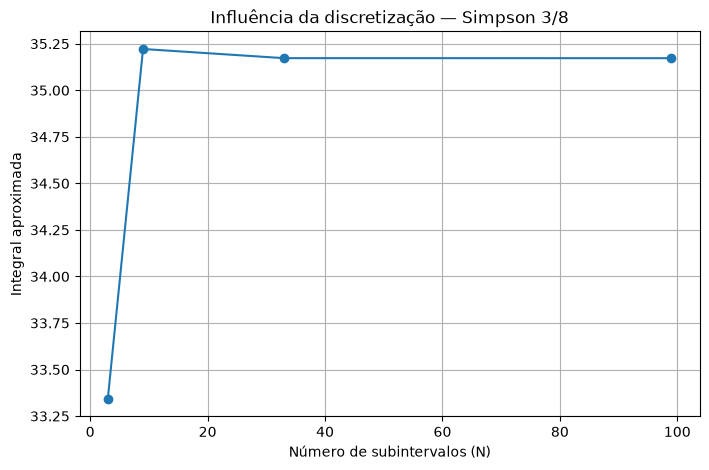

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def simpson_38_dados_composta(X, Y):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if len(X) != len(Y):
        raise ValueError("X e Y devem possuir o mesmo tamanho.")

    N = len(X) - 1

    if N % 3 != 0:
        raise ValueError("N deve ser múltiplo de 3.")

    h = np.diff(X)

    if not np.allclose(h, h[0]):
        raise ValueError("Os pontos de X devem possuir espaçamento uniforme.")

    soma = Y[0] + Y[-1]

    for i in range(1, N):
        if i % 3 == 0:
            soma += 2 * Y[i]
        else:
            soma += 3 * Y[i]

    return (3 * h[0] / 8) * soma


# Dados originais: 100 pontos
X = np.linspace(0, 10, 100)
Y = np.sin(X) + 0.1 * X**2

# Números de subintervalos desejados
N_valores = [3, 9, 33, 99]

resultados = []

for N in N_valores:

    # Seleção de N+1 pontos uniformemente distribuídos
    indices = np.linspace(0, len(X) - 1, N + 1, dtype=int)

    X_selecionado = X[indices]
    Y_selecionado = Y[indices]

    integral = simpson_38_dados_composta(
        X_selecionado,
        Y_selecionado
    )

    resultados.append([
        N,
        N + 1,
        integral
    ])


# Tabela de resultados
print(f"{'N':>8} {'Pontos':>10} {'Integral aproximada':>22}")
print("-" * 45)

for N, pontos, integral in resultados:
    print(f"{N:8d} {pontos:10d} {integral:22.10f}")


# Gráfico da integral em função de N
N_plot = [r[0] for r in resultados]
integral_plot = [r[2] for r in resultados]

plt.figure(figsize=(8, 5))
plt.plot(N_plot, integral_plot, 'o-')

plt.xlabel("Número de subintervalos (N)")
plt.ylabel("Integral aproximada")
plt.title("Influência da discretização — Simpson 3/8")
plt.grid(True)
plt.show()